# 02 · Operando bench protocol: simulation, multinuclear NMR and identifiability

Simulates the bench experiment of Peter Broqvist's `tmspa_hydrolysis_protocol.ipynb`. EC with 2 vol% water is stirred for 24 h and rested for 12 h; 5 vol% TMSPA is then added (t = 0). The sample is held 8 h at each of 20…80 °C and returned to 20 °C for a 1 h NMR acquisition after every hold. The notebook compares barrier models on this protocol and selects one. It then predicts the ²⁹Si, ³¹P, ¹³C and ¹H spectra of every acquisition and asks which reactions those spectra can tell apart.

Theory: [theory-multiscale_microkinetics.md](../docs/theory-multiscale_microkinetics.md) · guide: [guide-operando_experimental_protocol.md](../docs/guide-operando_experimental_protocol.md) · functions: [MODULES.md](../MODULES.md) · data: [data/README.md](../data/README.md) · models: `kinetics/models.py`

**Assumptions throughout**
- Inputs as in notebook 01: computed ωB97M-V G (298 K) and MACE ΔE_solv. ΔG_rxn does not change with T; only the Eyring prefactor and the Boltzmann factor do.
- Temperature changes are instantaneous. The 36 h pre-equilibration is chemically inert in this network (EC + H₂O hydrolysis is not modelled). EC melts at 36.4 °C, so the well-mixed assumption is weakest in the 20 and 30 °C holds.
- Shifts come from single gas-phase molecules: a few ppm off for ²⁹Si, ³¹P and ¹³C, more for OH. OH protons exchange fast and appear as one peak.
- There are no measured spectra yet. Every comparison is model against model, and the identifiability test (§7) is circular.

**Classification:** CONFIDENTIAL (see CLASSIFICATION.md) · **Source:** Y. Alcaraz Galván; outputs computed from P. Broqvist, Tank dataset snapshot (unpublished); protocol from P. Broqvist

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Make the repository importable whether the notebook runs from notebooks/ or from the repository root
REPO = Path.cwd() if (Path.cwd() / 'kinetics').is_dir() else Path.cwd().parent
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import numpy as np
import pandas as pd
from IPython.display import display

from kinetics import (
    NETWORK, MODELS, build_nmr_catalog, build_protocol_schedule, calculate_recipe_molarities,
    calculate_remaining_fraction, calculate_water_mass_balance, get_model, recover_reaction_extents,
    run_fingerprint_analysis, simulate_acquisition_spectra, simulate_protocol, tabulate_acquisitions,
    get_measured_shifts,
)
from demo import fingerprint_plots, nmr_plots, reactor_plots, style

style.apply_style()
pd.set_option('display.max_colwidth', None)

## 1. Recipe and protocol

Volume fractions → molarities, including the dilution when TMSPA is added; the stage table defines the protocol.

In [2]:
recipe = calculate_recipe_molarities(h2o_vol_frac_stock=0.02, tmspa_vol_frac=0.05)
stages, schedule = build_protocol_schedule()

print(f"H2O : TMSPA after injection = {recipe['h2o_tmspa_ratio']:.2f} : 1")
display(recipe['summary'].round(4))
schedule

H2O : TMSPA after injection = 7.04 : 1


,vol% (final),stock (M),after injection (M)
EC,93.1,14.7008,13.9657
H2O,1.9,1.1069,1.0515
TMSPA,5.0,0.0000,0.1494


,stage,T (°C),start (h),end (h),acquisition
0,"EC + H2O, stirred",20.0,-36.0,-12.0,
1,equilibrate,20.0,-12.0,0.0,
2,hold 20 °C,20.0,0.0,8.0,
3,acquire (20 °C),20.0,8.0,9.0,20 °C
4,hold 30 °C,30.0,9.0,17.0,
5,acquire (30 °C),20.0,17.0,18.0,30 °C
6,hold 40 °C,40.0,18.0,26.0,
7,acquire (40 °C),20.0,26.0,27.0,40 °C
8,hold 50 °C,50.0,27.0,35.0,
9,acquire (50 °C),20.0,35.0,36.0,50 °C


**Reading.** Water is in 7-fold excess, so TMSPA, not water, limits the phosphate ladder. Seven acquisitions sample the run, one after each hold.

## 2. Barrier models on the protocol: comparison

Every model runs the same protocol. (A) sweeps the single barrier of the capped-BEP reference, as in Peter's calibration; (B) compares the registered models. Both panels show what the experiment reads: TMSPA left at each acquisition.

,peter_reference,family_bep,family_marcus,level1
hold T (°C),,,,
20.0,0.996,0.0,0.0,0.0
30.0,0.982,0.0,0.0,0.0
40.0,0.923,0.0,0.0,0.0
50.0,0.731,0.0,0.0,0.0
60.0,0.339,0.0,0.0,0.0
70.0,0.043,0.0,0.0,0.0
80.0,0.000,0.0,0.0,0.0


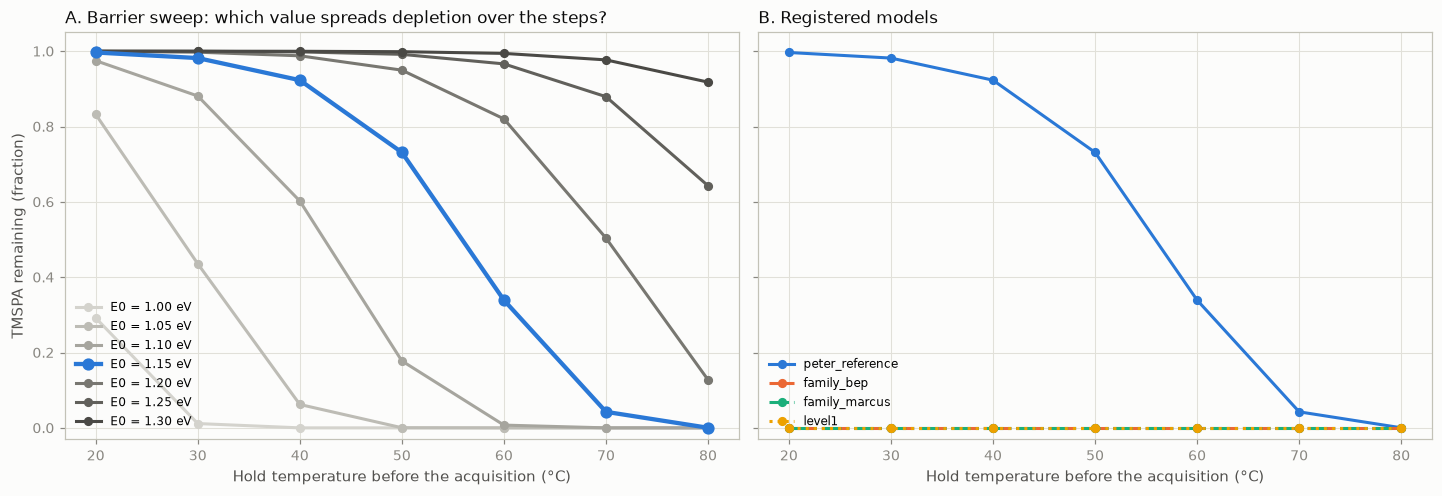

In [3]:
COMPARE = list(MODELS)
runs = {name: simulate_protocol(stages, recipe, model=name) for name in COMPARE}

reference = get_model('peter_reference')
sweep = {f'E0 = {g:.2f} eV': simulate_protocol(stages, recipe, model=reference.with_barrier(g))
         for g in (1.00, 1.05, 1.10, 1.15, 1.20, 1.25, 1.30)}

display(pd.DataFrame({name: calculate_remaining_fraction(sim) for name, sim in runs.items()}).round(3) + 0.0)
reactor_plots.plot_protocol_calibration(sweep, runs, highlight='E0 = 1.15 eV');

**Reading.**
- Only E0 ≈ 1.10–1.20 eV spreads TMSPA consumption over several acquisitions; with 1.15 eV most of it reacts in the 50–70 °C holds. At 1.00 eV it is gone by the 30 °C acquisition; at 1.30 eV only 8 % reacts by the end.
- The family and Level 1 models (hydrolysis and transfer g = 0.80 eV) consume all TMSPA before the first acquisition. If the experiment shows gradual consumption, their effective hydrolysis barriers must rise to about 1.1–1.2 eV (Finding 18).
- 1.15 eV is a design choice that makes the protocol informative, not a fit. The first measured ³¹P series will set it.

## 3. Model selection

Set `SELECTED_MODEL` to any registry name; everything below uses it.

In [4]:
SELECTED_MODEL = 'peter_reference'

sim = runs[SELECTED_MODEL]
model = get_model(SELECTED_MODEL)
print(f'{model.name} [{model.status}]: {model.label}')
for assumption in model.assumptions:
    print(f'  - {assumption}')
print('Element balance after injection:', ', '.join(f"{el} {'conserved' if ok else 'VIOLATED'}" for el, ok in sim['elements_conserved'].items()))

peter_reference [reference]: Peter reference: capped BEP, E0 = 1.15 eV for all reactions
  - One E0 for all 9 reactions, chosen so that TMSPA depletion spreads over the 20-80 °C holds (a design choice, not a fit to data)
  - Capped BEP: every exergonic step has ΔG‡ = E0, so ΔG_rxn does not rank their rates
  - Barrier depends on the direction a reaction is written (Finding 15)
Element balance after injection: Si conserved, P conserved


## 4. Concentrations through the protocol

Temperature program on top and the four product groups below; dotted lines mark the acquisitions. The table lists what each acquisition contains.

,TMSPA,BMSPA,MMSPA,H3PO4,H2O,TMSOH,HMDSO,TMSOEG,TMSOdiEG,CO2
hold T (°C),,,,,,,,,,
20.0,148.90,0.53,0.00,0.00,1050.99,0.51,0.00,0.01,0.00,0.01
30.0,146.69,2.71,0.03,0.00,1048.75,2.44,0.00,0.29,0.02,0.34
40.0,137.92,11.05,0.44,0.01,1039.58,7.30,0.04,3.22,1.36,5.95
50.0,109.28,34.19,5.35,0.60,1005.01,10.71,0.19,10.10,25.50,61.10
60.0,50.68,54.80,29.63,14.32,894.74,8.99,0.25,9.16,138.36,285.89
70.0,6.36,20.08,31.69,91.30,694.22,3.04,0.06,3.10,351.10,705.30
80.0,0.04,0.30,1.26,147.82,605.22,0.07,0.00,0.07,446.14,892.36


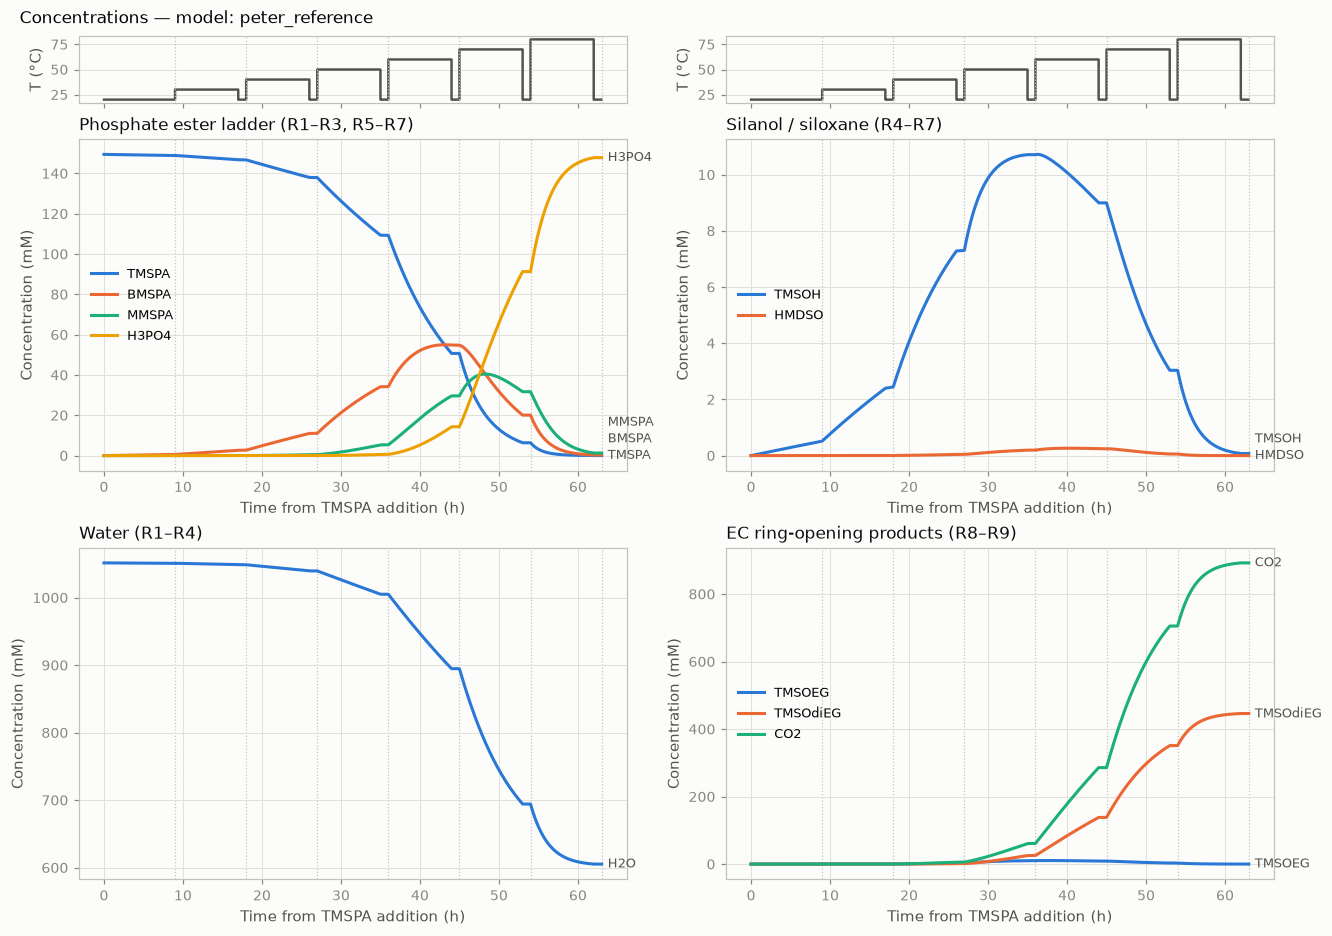

In [5]:
display(tabulate_acquisitions(sim).round(2))
reactor_plots.plot_concentration_panels(sim);

**Reading** (`peter_reference`).
- TMSPA → BMSPA → MMSPA → H₃PO₄ runs as a sequential ladder, each intermediate peaking one or two holds after its parent; every hold leaves a kink.
- TMSOH peaks at about 11 mM during the 40–50 °C holds and is consumed by EC ring-opening (R8, R9): CO₂ reaches about 0.9 M. HMDSO stays below 0.3 mM because condensation (R4) is uphill.
- Water falls from 1.05 M to 0.61 M.

### 4.1 Level 1 with the hydrolysis barrier from notebook 03

Same protocol under `level1`, with the hydrolysis g raised to 1.30 eV: the value highlighted in notebook 03 §5, inside the band where the step protocol stays informative (1.25–1.40 eV). The other families keep their `level1` values.

,TMSPA,BMSPA,MMSPA,H3PO4,H2O,TMSOH,HMDSO,TMSOEG,TMSOdiEG,CO2
hold T (°C),,,,,,,,,,
20.0,54.48,94.94,0.01,0.00,1004.04,0.00,47.48,0.00,0.00,0.00
30.0,1.19,148.16,0.07,0.00,977.36,0.00,74.15,0.00,0.00,0.00
40.0,0.01,142.30,6.48,0.64,972.74,0.38,78.39,0.00,0.00,0.00
50.0,0.00,119.94,21.30,8.17,957.08,1.77,92.64,0.00,0.02,0.04
60.0,0.00,65.51,37.51,46.40,907.25,8.33,135.48,0.01,0.44,0.90
70.0,0.00,7.49,20.52,121.41,814.52,51.67,175.78,0.07,9.47,19.02
80.0,0.00,0.58,6.17,142.68,715.79,120.85,105.23,0.17,109.47,219.11


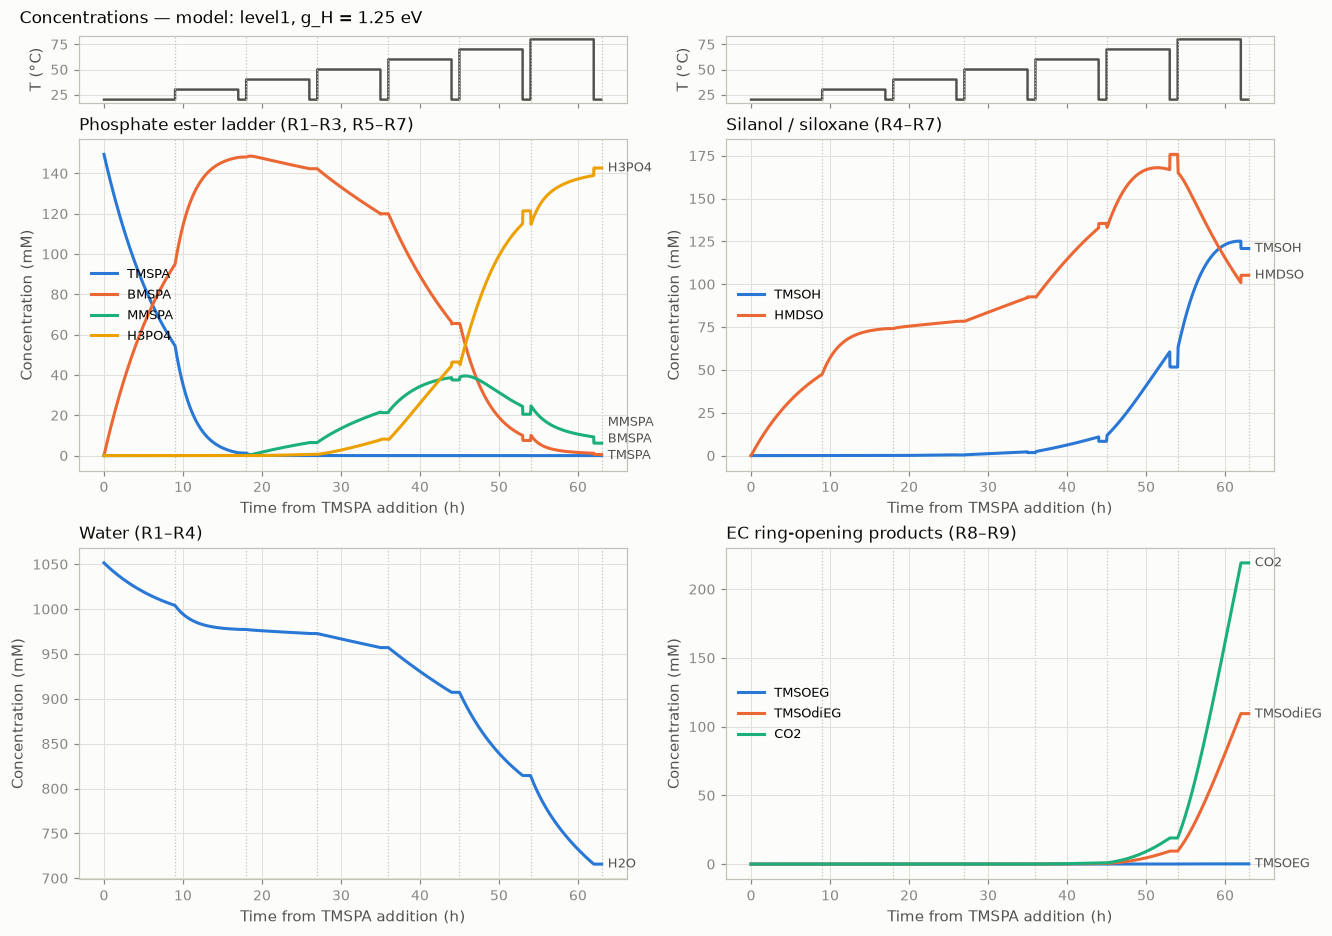

In [21]:
G_HYDROLYSIS_NB03 = 1.25  # eV, notebook 03 §5
level1_nb03 = get_model('level1').with_family_params('hydrolysis', g_eV=G_HYDROLYSIS_NB03,
                                                     name=f'level1, g_H = {G_HYDROLYSIS_NB03:.2f} eV')
sim_level1 = simulate_protocol(stages, recipe, model=level1_nb03)

display(tabulate_acquisitions(sim_level1).round(2))
reactor_plots.plot_concentration_panels(sim_level1);

## 5. Predicted NMR spectra

One trace per acquisition for each nucleus, then ³¹P through the whole run: four separated peaks with one P each, the cleanest readout for fitting the barrier. Dashed lines: shifts measured by Gogoi et al. 2024 (²⁹Si, ³¹P).

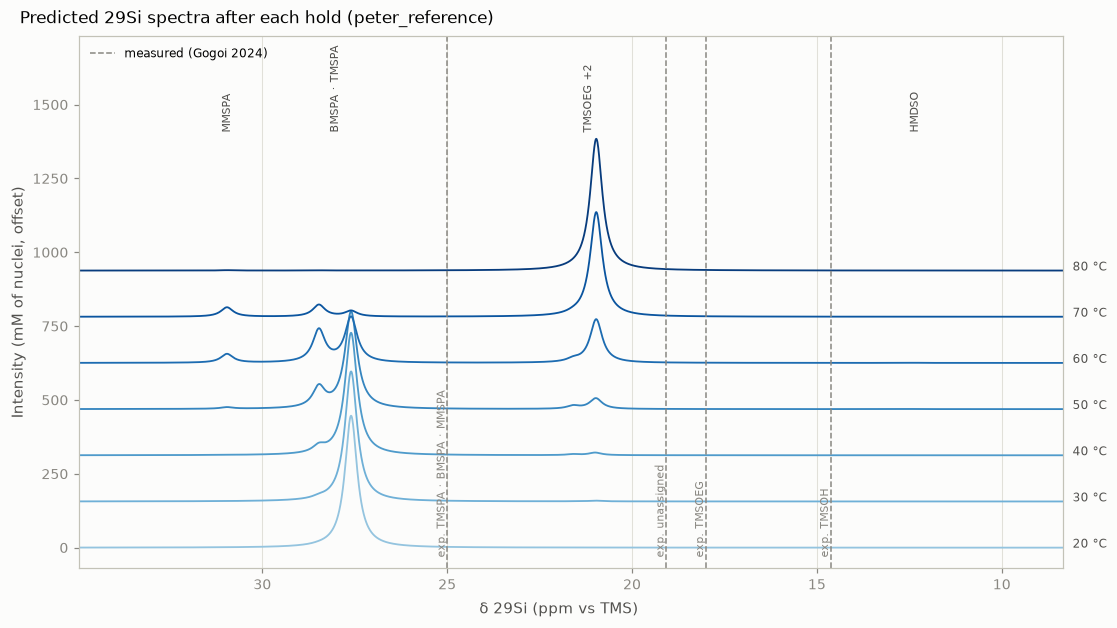

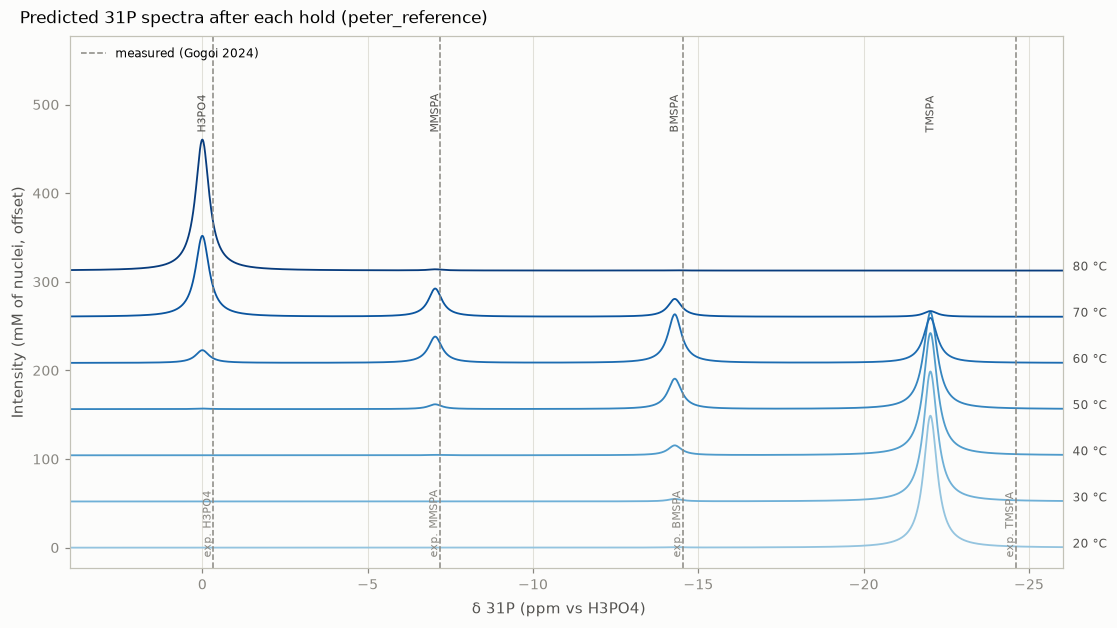

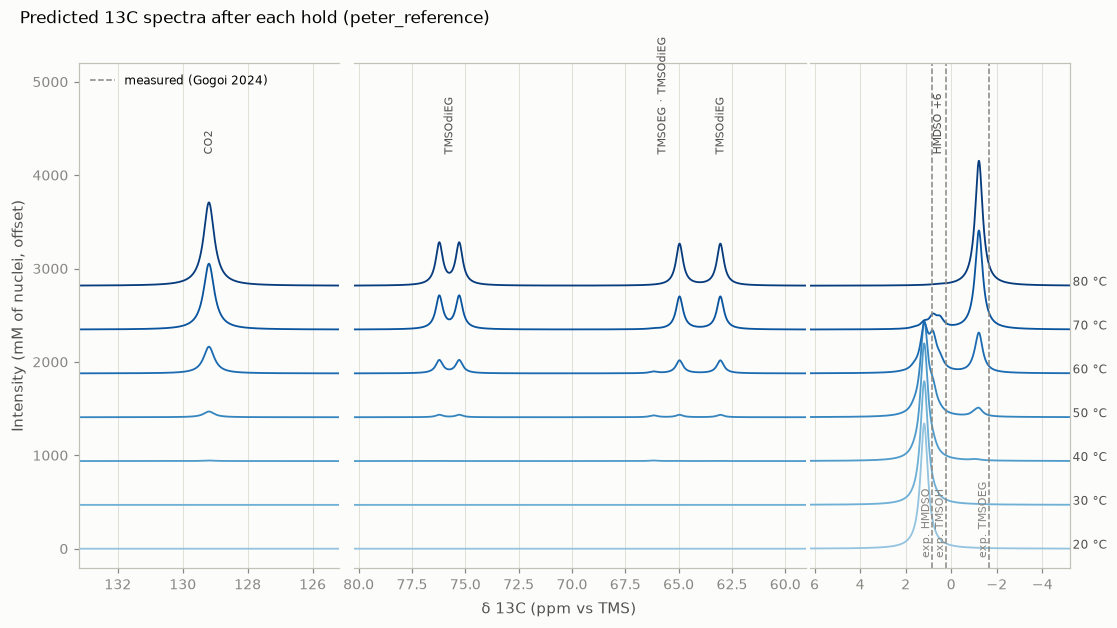

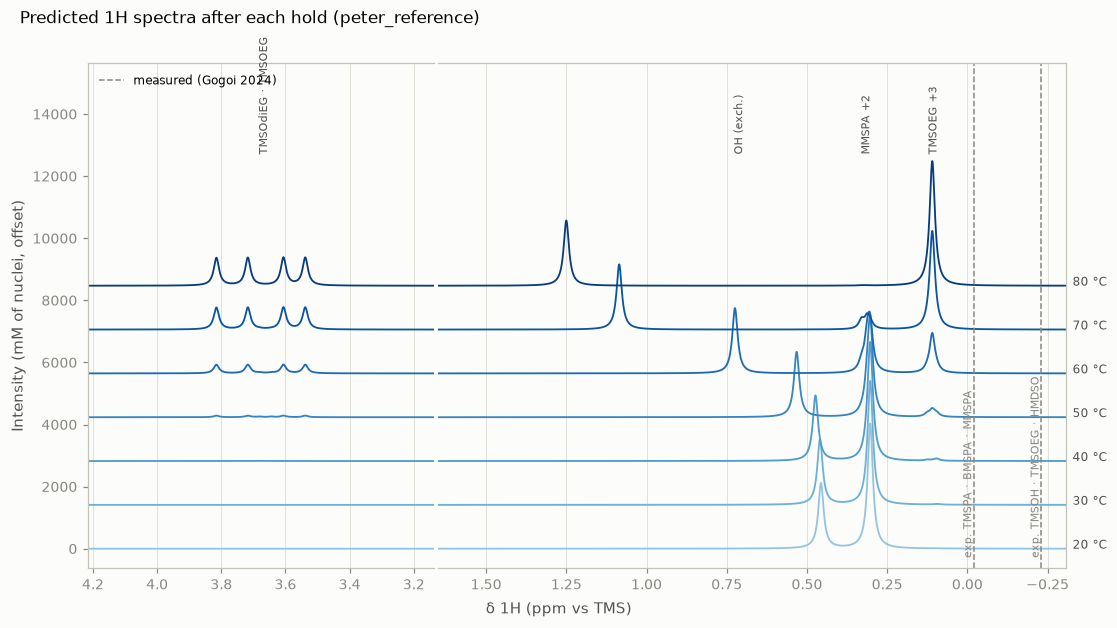

In [7]:
nmr_catalog = build_nmr_catalog()
exp_shifts = get_measured_shifts()
for element in ('Si', 'P', 'C', 'H'):
    nmr_plots.plot_stacked_spectra(sim, element, nmr_catalog, experimental=exp_shifts)

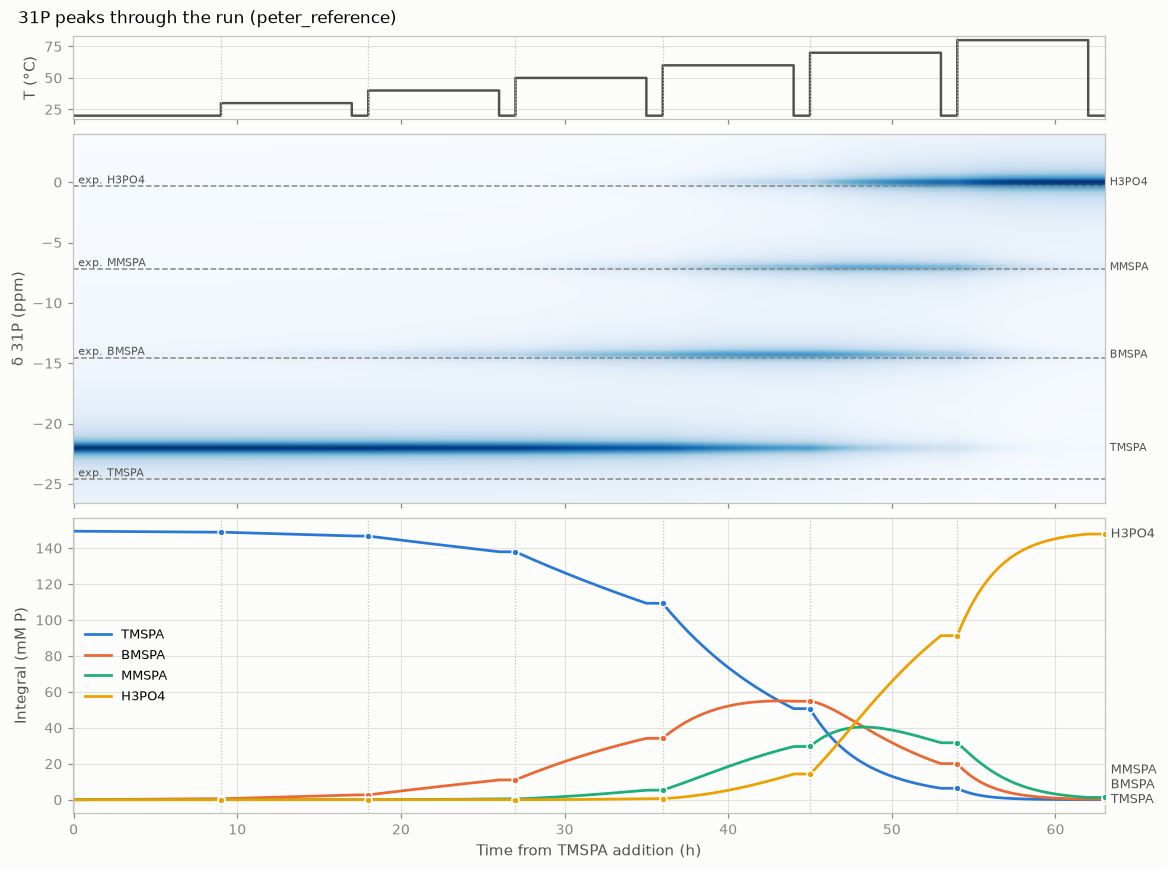

In [8]:
nmr_plots.plot_peak_tracking(sim, 'P', nmr_catalog, experimental=exp_shifts);

**Reading.**
- ³¹P resolves the whole phosphate ladder (TMSPA −22.0, BMSPA −14.3, MMSPA −7.0, H₃PO₄ 0 ppm), within 2.6 ppm of the measured positions (TMSPA −24.6, BMSPA −13.9…−15.2, MMSPA −6.4…−8.0, H₃PO₄ −0.3 ppm).
- ²⁹Si: the xMSPA triplet overlaps at 27.6–31 ppm (measured as one band at ≈ 25 ppm), and TMSOH, TMSOEG and TMSOdiEG overlap near 21 ppm. Every computed ²⁹Si line sits 3–6 ppm above its measured position.
- ¹³C: CO₂ (≈ 129 ppm) and the glycol carbons (60–77 ppm) track EC ring-opening; all methyl carbons sit near 0 ppm.
- ¹H: the exchange-averaged OH peak moves as its carriers change (§6). Its absolute position is only indicative: gas-phase water computes at 0.46 ppm against 2–3 ppm measured in wet carbonates.

## 6. Water from ¹H

No reaction destroys an OH proton, so the exchange-averaged OH integral stays at 2·[H₂O]₀ and cannot measure water. Water follows instead from the resolved peaks of the other OH carriers: [H₂O] = [H₂O]₀ − ½ Σ n_OH,i C_i.

max |mass balance − simulated [H2O]| = 8.9e-16 M


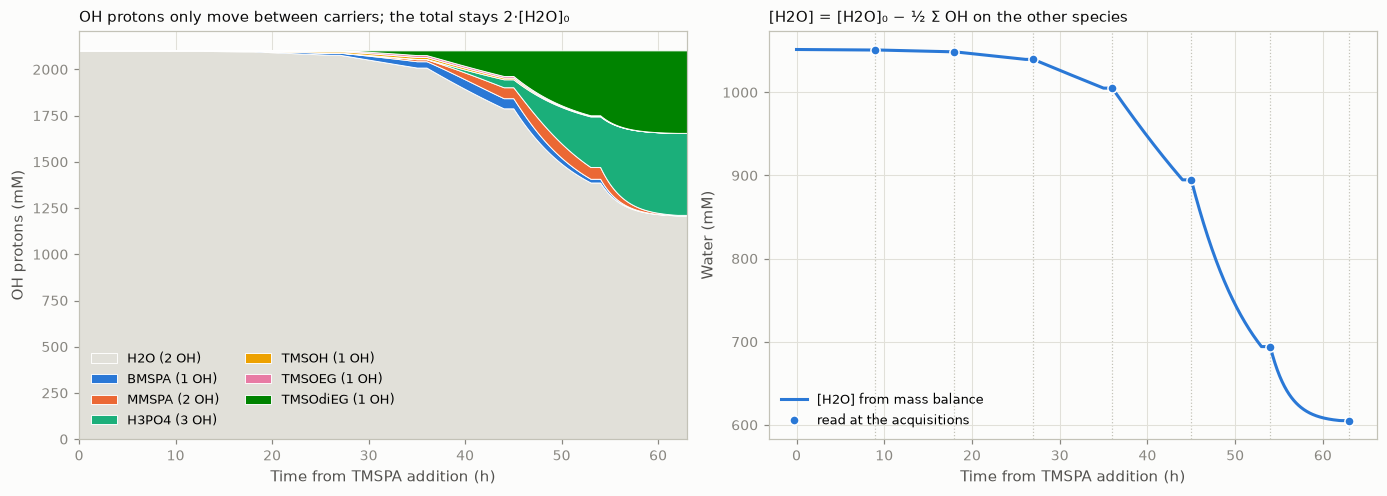

In [9]:
water = calculate_water_mass_balance(sim['C_M'], sim['idx'], recipe['after']['H2O'], nmr_catalog)
post = slice(sim['injection_idx'], None)
print(f"max |mass balance − simulated [H2O]| = {np.max(np.abs(water['h2o_mass_balance_M'][post] - water['h2o_direct_M'][post])):.1e} M")
nmr_plots.plot_water_balance(sim, water);

**Reading.** The OH protons move from water to H₃PO₄ (3 OH each) and TMSOdiEG while their total stays constant. The mass balance reproduces the simulated water exactly; with real spectra it needs [H₂O]₀ from a Karl Fischer titration before TMSPA is added.

## 7. Which reactions can the spectra tell apart?

Each reaction changes all four spectra in a fixed pattern, its fingerprint. The rank of the fingerprints gives the identifiable (lumped) reactions. The Net Analyte Signal gives, per nucleus, the share of each fingerprint that no other reaction can mimic. The per-step extents are then recovered from noisy synthetic acquisitions.

Rank 6 of 9 reactions. Identifiable: R1 ⊕ R5; R2 ⊕ R6; R3 ⊕ R7; R4 ⊕ R5,R6,R7; R8; R9


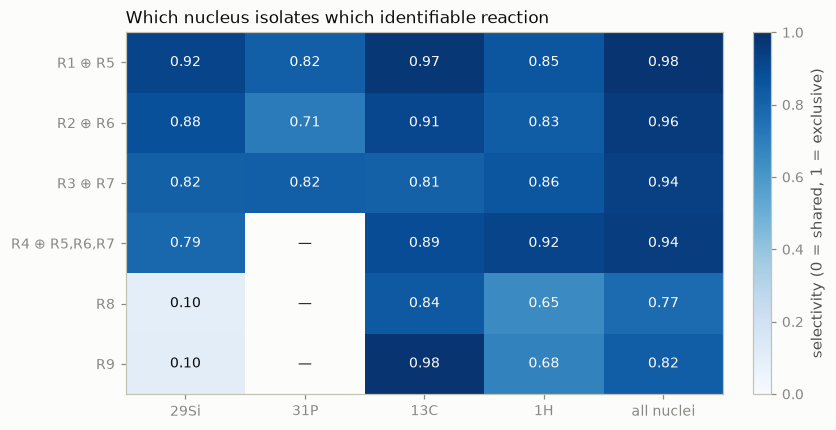

In [10]:
fingerprints = run_fingerprint_analysis(NETWORK, nmr_catalog=nmr_catalog)
print(f"Rank {fingerprints['effective_rank']} of {len(NETWORK)} reactions. "
      f"Identifiable: {'; '.join(fingerprints['lumped_labels'])}")
fingerprint_plots.plot_selectivity(fingerprints['selectivity']);

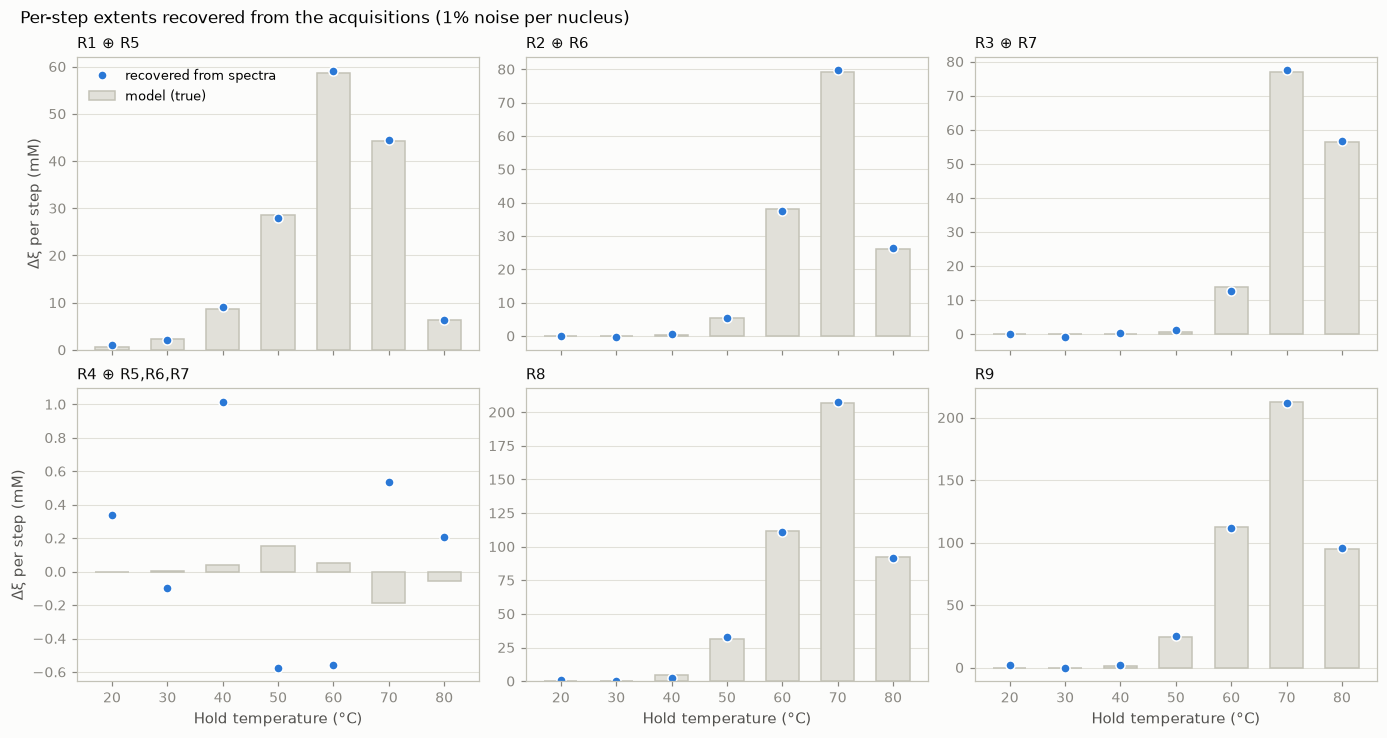

In [11]:
NOISE_REL = 0.01    # Gaussian noise, fraction of each nucleus' maximum

dD_true = np.diff(simulate_acquisition_spectra(sim, fingerprints), axis=0)
dD_noisy = np.diff(simulate_acquisition_spectra(sim, fingerprints, noise_rel=NOISE_REL), axis=0)
xi_true = recover_reaction_extents(dD_true, fingerprints['F_basis_norm'], fingerprints['weights'])
xi_noisy = recover_reaction_extents(dD_noisy, fingerprints['F_basis_norm'], fingerprints['weights'])
fingerprint_plots.plot_extent_recovery([a['T_C'] for a in sim['acquisitions']], xi_true, xi_noisy,
                                       fingerprints['lumped_labels'], NOISE_REL);

**Reading.**
- Only 6 of the 9 reactions are identifiable. Silanolysis R5–R7 has the same net effect as hydrolysis plus condensation (R_k + R4) in every nucleus; only their rate laws could separate them.
- ¹³C separates every lumped reaction. ²⁹Si barely sees EC ring-opening (R8, R9: selectivity 0.10), and ³¹P sees only the phosphate ladder.
- With 1 % noise the large extents are recovered; the tiny condensation extent (R4 ⊕ …) is noise-dominated. The test is circular (the same computed shifts generate and analyse the data) and assumes a t = 0 spectrum, which the current protocol does not record.